# Studio dataset + labeling

link:https://cs.stanford.edu/people/dorarad/gqa/download.html

In [1]:
import json
import random
import pandas as pd

#pd.set_option("display.max_colwidth", None)
#pd.set_option("display.max_rows", None)
#pd.set_option("display.max_columns", None)

random.seed(42)

with open("../data/sceneGraphs/train_sceneGraphs.json") as f:
    data_train = json.load(f)

with open("../data/sceneGraphs/val_sceneGraphs.json") as f:
    data_val = json.load(f)

all_train_keys = list(data_train.keys())
all_val_keys = list(data_val.keys())

print(f"Totale record train: {len(all_train_keys)}")
print(f"Totale record val: {len(all_val_keys)}\n")

part = 0.3

k = max(1, int(len(all_train_keys) * part))
train_keys = random.sample(all_train_keys, k)

k = max(1, int(len(all_val_keys) * part))
val_keys = random.sample(all_val_keys, k)

print(f"record train: {int(len(all_train_keys) * part)}")
print(f"record val: {int(len(all_val_keys) * part)}")

Totale record train: 74942
Totale record val: 10696

record train: 22482
record val: 3208


In [2]:
small_data_train = {k: data_train[k] for k in train_keys}
small_data_val = {k: data_val[k] for k in val_keys}


In [3]:

df_train = pd.DataFrame.from_dict(small_data_train, orient="index")
df_train.reset_index(inplace=True)
df_train.rename(columns={"index": "image_id"}, inplace=True)

df_val = pd.DataFrame.from_dict(small_data_val, orient="index")
df_val.reset_index(inplace=True)
df_val.rename(columns={"index": "image_id"}, inplace=True)

In [4]:
display("train:",df_train.head())
display("val:",df_val.head())

'train:'

,image_id,width,objects,location,height,weather
0,2328363,500,"{'977890': {'name': 'helmet', 'h': 39, 'relati...",outdoors,333,NaN
1,2379201,375,"{'1359959': {'name': 'sky', 'h': 341, 'relatio...",NaN,500,NaN
2,2387152,333,"{'1278776': {'name': 'woman', 'h': 392, 'relat...",NaN,500,NaN
3,2379505,500,"{'1356974': {'name': 'man', 'h': 333, 'relatio...",NaN,375,NaN
4,2407089,500,"{'323736': {'name': 'boot', 'h': 27, 'relation...",NaN,375,NaN


'val:'

,image_id,width,objects,location,height,weather
0,2325919,500,"{'984369': {'name': 'cabinet', 'h': 96, 'relat...",indoors,282,NaN
1,2384976,333,"{'1302561': {'name': 'table', 'h': 132, 'relat...",NaN,500,NaN
2,2327398,500,"{'3970490': {'name': 'sky', 'h': 114, 'relatio...",outdoors,438,cloudy
3,2384106,500,"{'528418': {'name': 'bags', 'h': 70, 'relation...",NaN,421,NaN
4,2415221,500,"{'3970837': {'name': 'book', 'h': 103, 'relati...",NaN,333,NaN


In [5]:
print(df_train["location"].drop_duplicates().to_string(index=False))

outdoors
     NaN
 indoors


Notata assenza etichette 

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def show_image_grid_from_df(df, image_dir, cols=5, id_col="image_id", label_col=None, max_images=25):
    """
    Mostra una griglia pulita e proporzionata di immagini a partire da un DataFrame.
    """
    # 1. Filtra preventivamente solo le righe le cui immagini esistono davvero sul disco
    valid_rows = []
    for _, row in df.head(max_images * 2).iterrows(): # Controlla un po' di righe in più in caso di missing
        img_id = row[id_col]
        # Gestisce sia ID puri (es. 12345) sia nomi file completi (es. 12345.jpg)
        filename = str(img_id) if str(img_id).lower().endswith(('.jpg', '.jpeg', '.png')) else f"{img_id}.jpg"
        img_path = os.path.join(image_dir, filename)
        
        if os.path.exists(img_path):
            valid_rows.append((img_path, row[label_col] if label_col else img_id))
        if len(valid_rows) == max_images:
            break

    num_images = len(valid_rows)
    if num_images == 0:
        print(f"Nessuna immagine valida trovata in: {image_dir}")
        return

    # 2. Calcola righe e colonne effettive
    rows = (num_images + cols - 1) // cols
    
    # 3. Imposta una dimensione della figura proporzionata (es. 3 unità di larghezza e 3 di altezza per immagine)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
    
    # Appiattisce l'array degli assi per poterlo iterare linearmente senza badare alla matrice righe x colonne
    axes = axes.flatten() if num_images > 1 else [axes]

    # 4. Popola la griglia
    for i in range(len(axes)):
        if i < num_images:
            img_path, title_text = valid_rows[i]
            try:
                img = Image.open(img_path).convert("RGB")
                axes[i].imshow(img)
                
                # Formatta il titolo (accorcia se troppo lungo per evitare sovrapposizioni)
                title_str = str(title_text)
                if len(title_str) > 25:
                    title_str = title_str[:22] + "..."
                    
                axes[i].set_title(title_str, fontsize=9, fontweight='semibold', pad=8)
            except Exception as e:
                axes[i].text(0.5, 0.5, "Error Load", ha='center', va='center', color='red')
        
        # Disattiva gli assi per TUTTI i subplot (inclusi quelli vuoti finali)
        axes[i].axis("off")

    # 5. Ottimizza lo spazio tra i subplot per evitare sovrapposizioni tra titoli e immagini
    plt.tight_layout()
    plt.show()

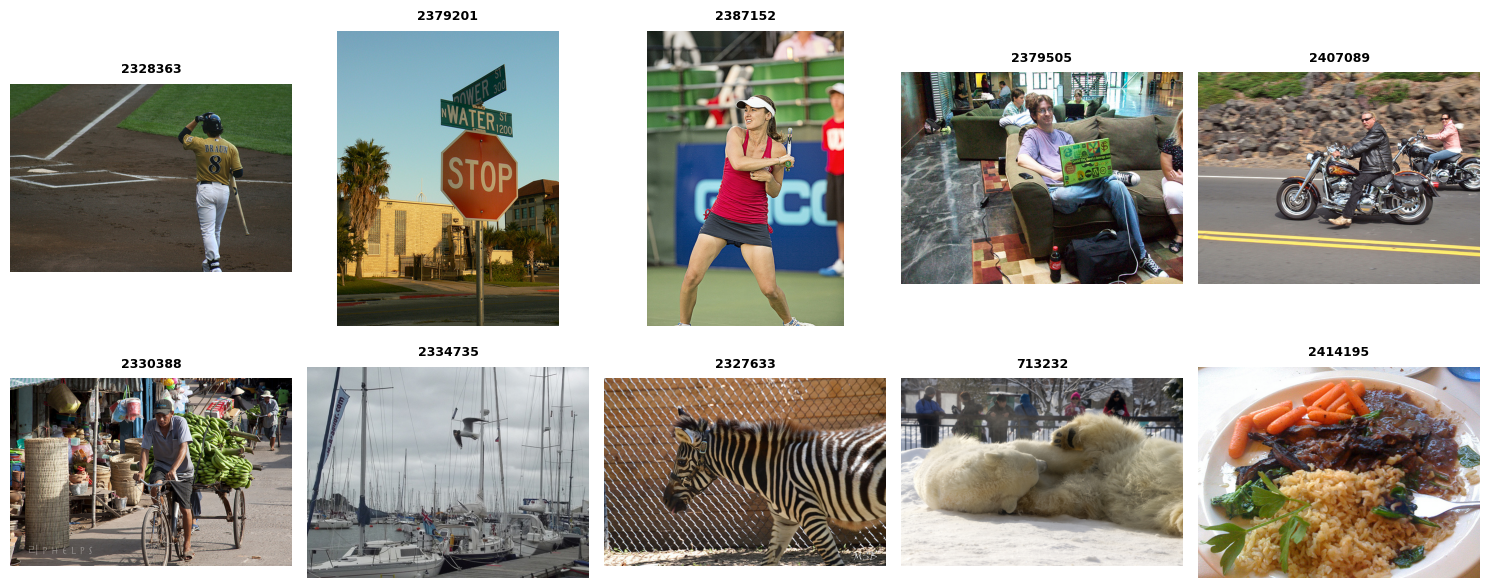

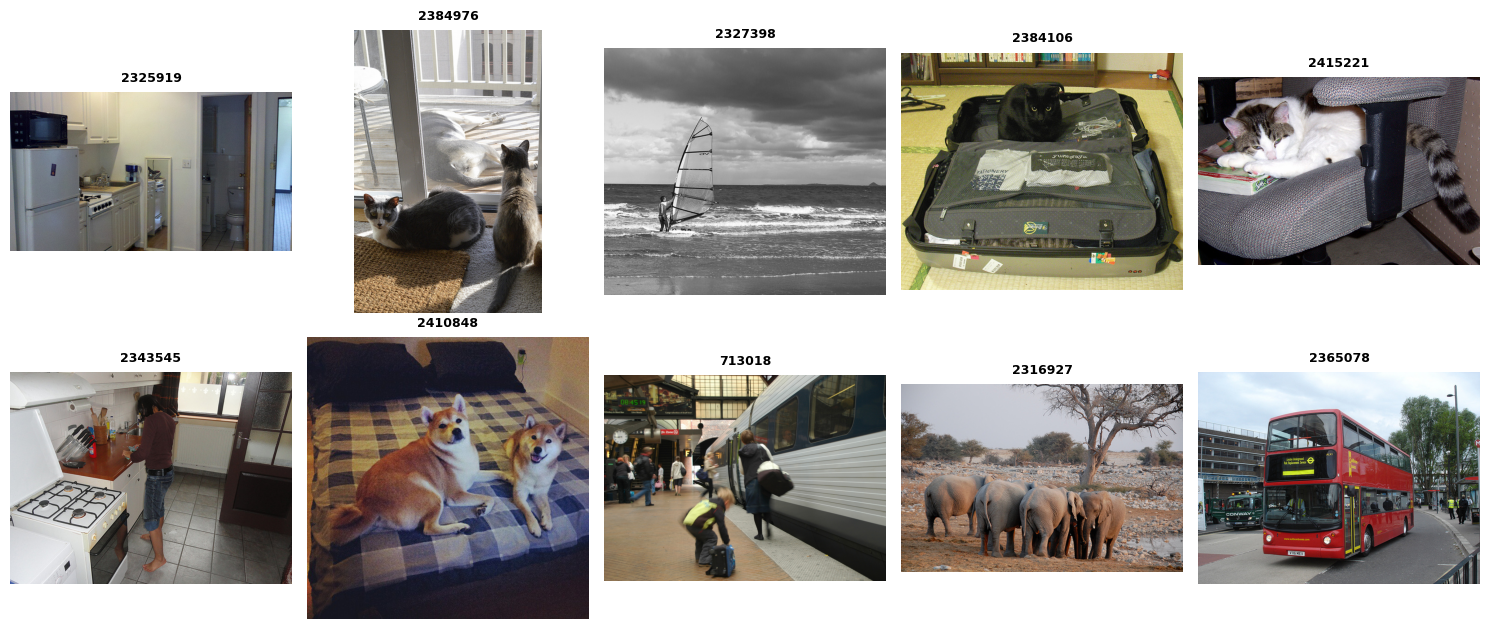

In [7]:
show_image_grid_from_df(
    df=df_train,
    image_dir="../data/images",
    cols=5,
    max_images=10
)

show_image_grid_from_df(
    df=df_val,
    image_dir="../data/images",
    cols=5,
    max_images=10
)

In [8]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_by_id(df, image_id, image_dir, id_col="image_id"):
    
    # 1. trova la riga
    row = df[df[id_col] == str(image_id)]

    if row.empty:
        print(f"Image ID {image_id} non trovato nel DataFrame")
        return

    row = row.iloc[0]

    # 2. stampa informazioni
    print("📌 Informazioni record:")
    print(row)
    print("\n")

    # 3. carica immagine
    img_path = os.path.join(image_dir, f"{image_id}.jpg")

    if not os.path.exists(img_path):
        print(f"Immagine non trovata: {img_path}")
        return

    img = Image.open(img_path).convert("RGB")

    # 4. mostra immagine
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Image ID: {image_id}")
    plt.axis("off")
    plt.show()

In [9]:
# show_sample_by_id(df=df,image_id=2400612,image_dir="../data/images")

In [10]:
import pandas as pd

def extract_objects(df, col_input, col_output="objects"):
    """
    Estrae i nomi degli oggetti da un scene graph GQA
    e rimuove i duplicati mantenendo l'ordine.
    """

    def get_objects(scene_graph):
        if not isinstance(scene_graph, dict):
            return []

        objects = []
        seen = set()

        for obj_id, obj_data in scene_graph.items():
            if isinstance(obj_data, dict) and "name" in obj_data:
                name = obj_data["name"]

                if name not in seen:
                    objects.append(name)
                    seen.add(name)

        return objects

    df[col_output] = df[col_input].apply(get_objects)

    return df

In [11]:
df_train_n = extract_objects(df_train, "objects","obj_list")
df_val_n = extract_objects(df_val, "objects","obj_list")

In [12]:
display(df_train_n.head(5))
display(df_val_n.head(5))

,image_id,width,objects,location,height,weather,obj_list
0,2328363,500,"{'977890': {'name': 'helmet', 'h': 39, 'relati...",outdoors,333,NaN,"[helmet, shirt, hand, head, pants, belt, field..."
1,2379201,375,"{'1359959': {'name': 'sky', 'h': 341, 'relatio...",NaN,500,NaN,"[sky, building, roof, house, road, pole, sign,..."
2,2387152,333,"{'1278776': {'name': 'woman', 'h': 392, 'relat...",NaN,500,NaN,"[woman, shoe, ring, head, arm, pole, leg, polo..."
3,2379505,500,"{'1356974': {'name': 'man', 'h': 333, 'relatio...",NaN,375,NaN,"[man, couch, bottle, rug, laptop, shoes, woman..."
4,2407089,500,"{'323736': {'name': 'boot', 'h': 27, 'relation...",NaN,375,NaN,"[boot, people, wheel, coat, bike, woman, shoe,..."


,image_id,width,objects,location,height,weather,obj_list
0,2325919,500,"{'984369': {'name': 'cabinet', 'h': 96, 'relat...",indoors,282,NaN,"[cabinet, mirror, refrigerator, stove, microwa..."
1,2384976,333,"{'1302561': {'name': 'table', 'h': 132, 'relat...",NaN,500,NaN,"[table, cat, patio, carpet, chair, tail, dog, ..."
2,2327398,500,"{'3970490': {'name': 'sky', 'h': 114, 'relatio...",outdoors,438,cloudy,"[sky, guy, hand, water, ocean, cloud, beach, s..."
3,2384106,500,"{'528418': {'name': 'bags', 'h': 70, 'relation...",NaN,421,NaN,"[bags, ear, nose, eye, cat, floor, sticker, sh..."
4,2415221,500,"{'3970837': {'name': 'book', 'h': 103, 'relati...",NaN,333,NaN,"[book, paw, wall, fur, tail, seat, wallpaper, ..."


In [13]:
count = df_val_n["obj_list"].apply(
    lambda x: isinstance(x, list) and "living room" in x
).sum()

print(count)

8


Generiamo etichette usando CLIP di OpenAI

In [14]:
import clip
import torch
from PIL import Image
import os

def assign_room_clip(df, image_path_col, images_dir):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)

    model, preprocess = clip.load("ViT-B/32", device=device)

    labels = [
        "a kitchen interior",
        "a bedroom interior",
        "a bathroom interior",
        "a living room interior",
        #"a natural outdoor scene",

        "a street scene in a city",
        "a railway scene",
        #"an airport runway",
        "an airplane flying in the sky",

        "a person playing a sport",

        "a wild animal in nature",
        "a beach scene",
        "a countryside landscape",
        #"a building",

        "a food scene",
        "a building exterior",
        "a restaurant dining scene",
        #"a restaurant"
    ]

    
    text = clip.tokenize(labels).to(device)

    results = []
    

    for _, row in df.iterrows():

        img_path = os.path.join(images_dir, row[image_path_col]+".jpg")
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)

            logits = image_features @ text_features.T
            probs = logits.softmax(dim=-1)

            pred = labels[probs.argmax().item()]

        results.append(pred)

    df["labels"] = results

    return df

In [15]:
df_clip = assign_room_clip(df_val_n, "image_id", "../data/images")

cuda


In [16]:
display(df_clip.head()) 

,image_id,width,objects,location,height,weather,obj_list,labels
0,2325919,500,"{'984369': {'name': 'cabinet', 'h': 96, 'relat...",indoors,282,NaN,"[cabinet, mirror, refrigerator, stove, microwa...",a kitchen interior
1,2384976,333,"{'1302561': {'name': 'table', 'h': 132, 'relat...",NaN,500,NaN,"[table, cat, patio, carpet, chair, tail, dog, ...",a food scene
2,2327398,500,"{'3970490': {'name': 'sky', 'h': 114, 'relatio...",outdoors,438,cloudy,"[sky, guy, hand, water, ocean, cloud, beach, s...",a beach scene
3,2384106,500,"{'528418': {'name': 'bags', 'h': 70, 'relation...",NaN,421,NaN,"[bags, ear, nose, eye, cat, floor, sticker, sh...",a wild animal in nature
4,2415221,500,"{'3970837': {'name': 'book', 'h': 103, 'relati...",NaN,333,NaN,"[book, paw, wall, fur, tail, seat, wallpaper, ...",a food scene


In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_samples_per_label(df, image_path_col, images_dir, label_col="labels", n=12):

    labels = df[label_col].unique()

    for label in labels:
        subset = df[df[label_col] == label].head(n)

        if subset.empty:
            continue

        plt.figure(figsize=(15, 3))
        plt.suptitle(label, fontsize=16)

        for i, (_, row) in enumerate(subset.iterrows()):
            img_path = os.path.join(images_dir, row[image_path_col] + ".jpg")

            try:
                img = Image.open(img_path).convert("RGB")
            except:
                continue

            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.axis("off")

        plt.show()

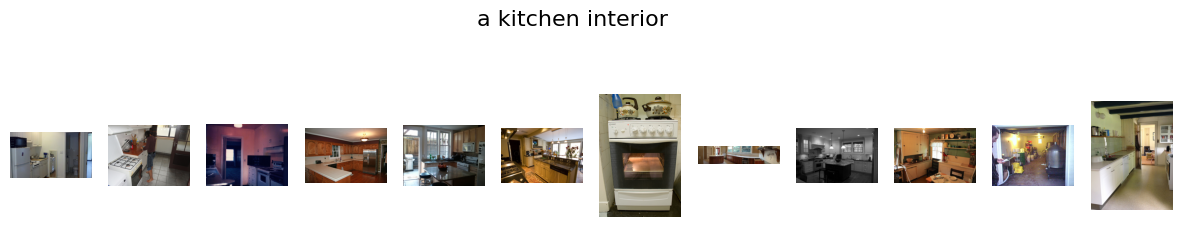

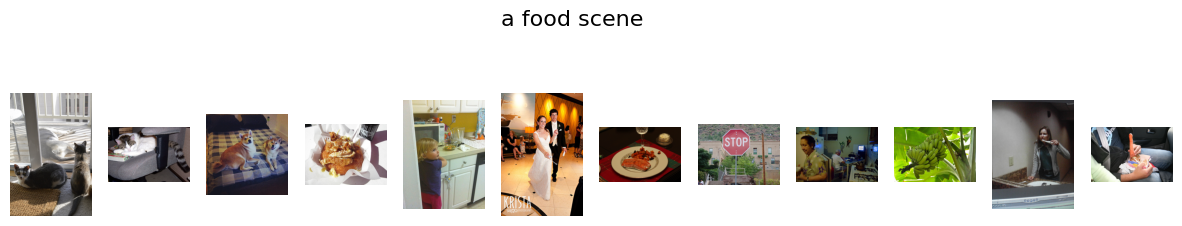

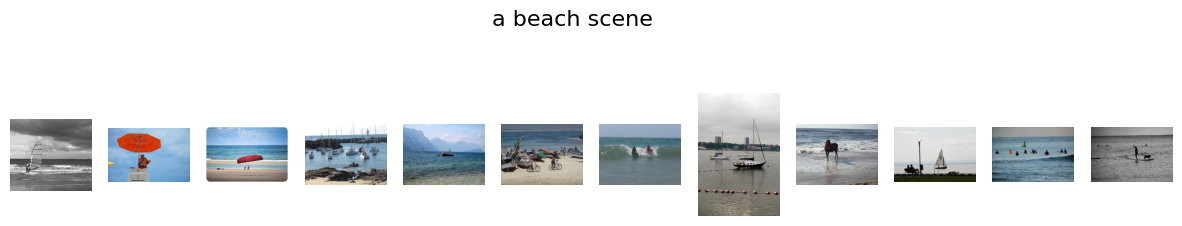

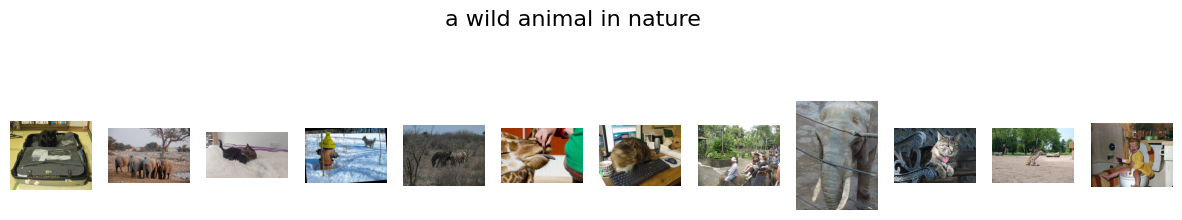

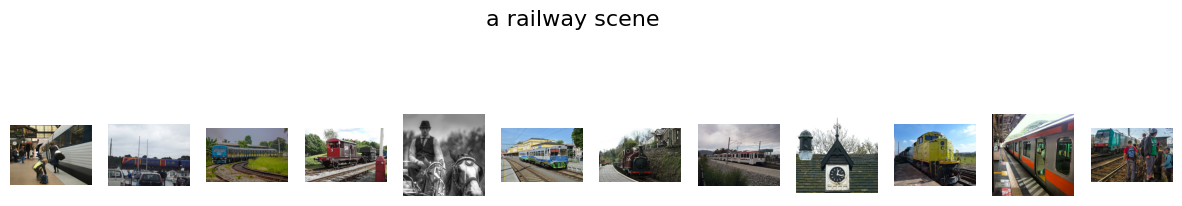

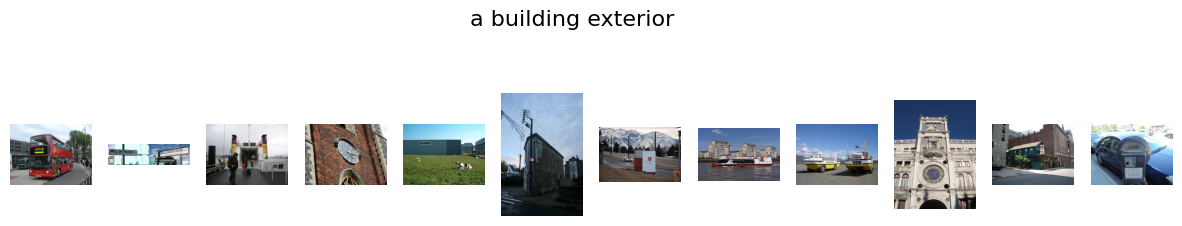

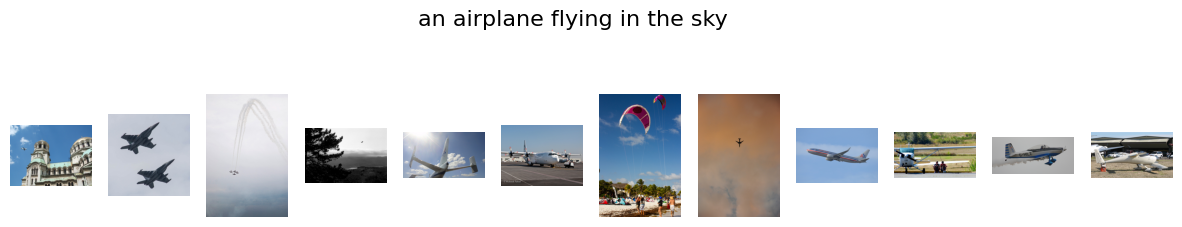

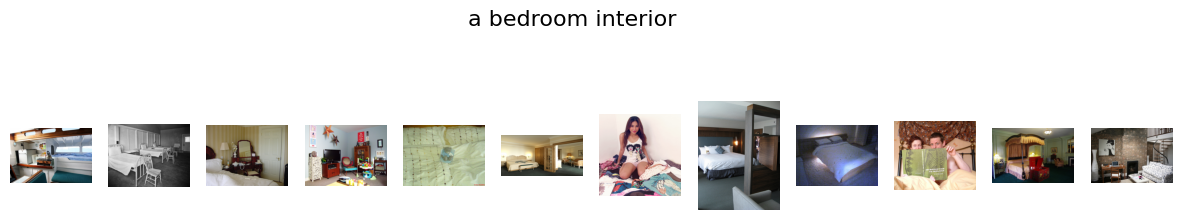

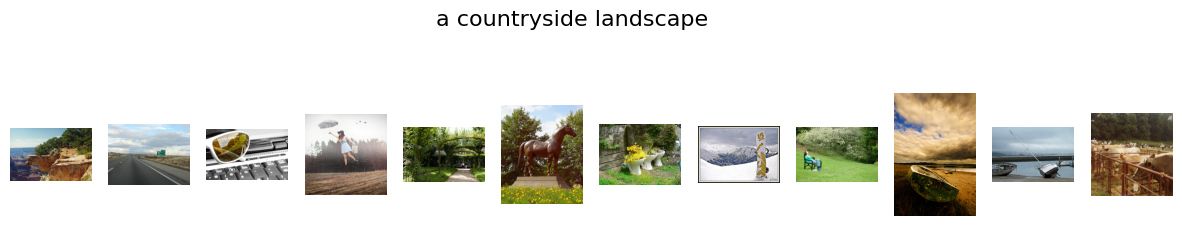

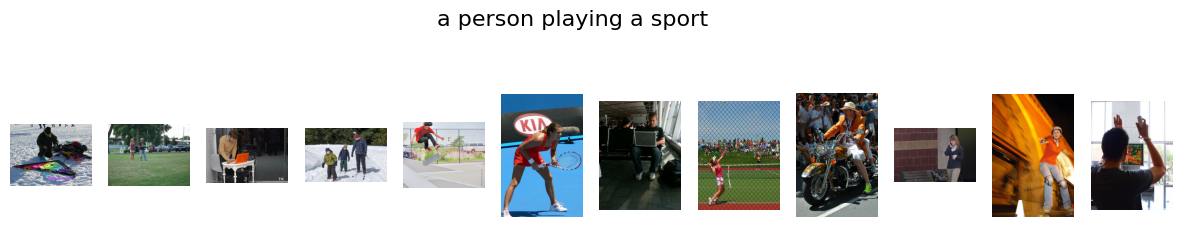

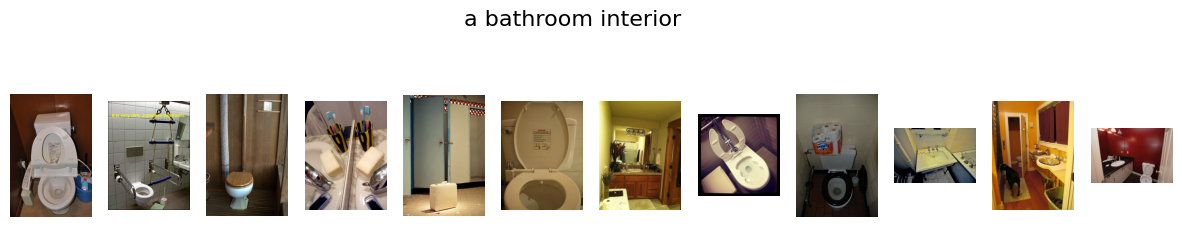

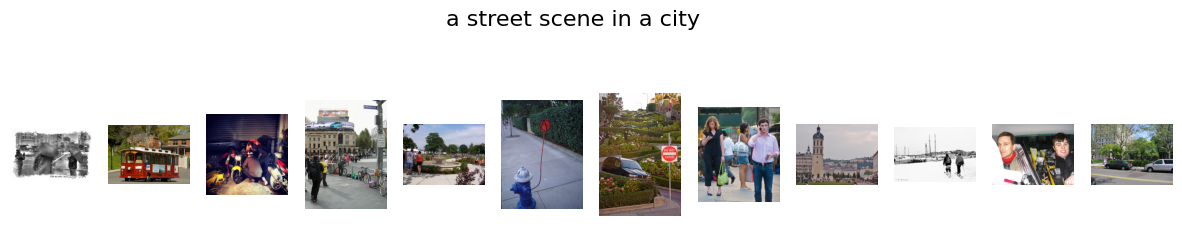

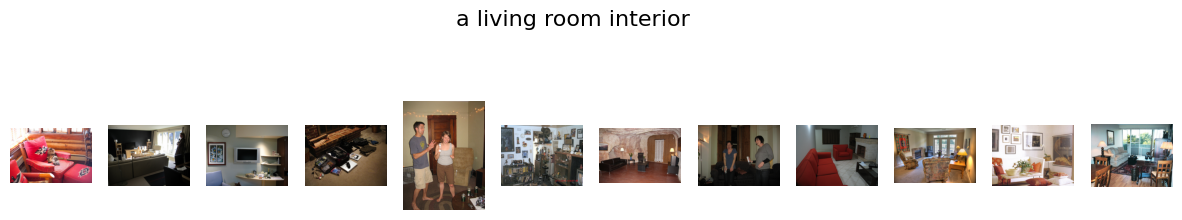

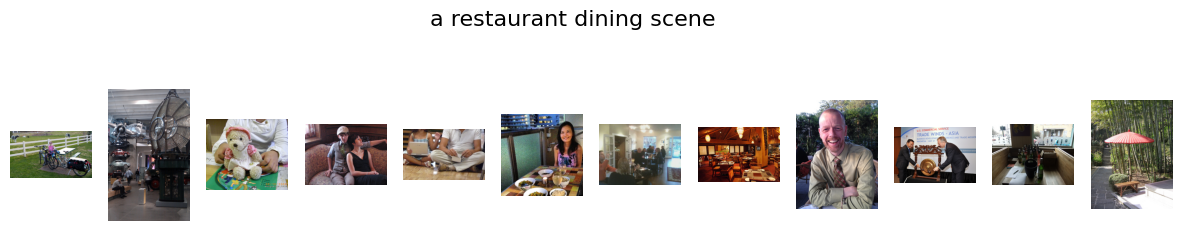

In [18]:
show_samples_per_label(df_clip, "image_id", "../data/images")

In [19]:
import matplotlib.pyplot as plt

def analyze_class_distribution(df, top_k=None, show_plots=True):
    label_counts = df['labels'].value_counts()

    print("\n📌 Conteggio immagini per classe:\n")
    for label, count in label_counts.items():
        print(f"{label}: {count}")

    print(f"\nTotale immagini: {len(df)}")
    print(f"Numero classi: {label_counts.shape[0]}")

    # opzionale: top_k
    if top_k is not None:
        label_counts = label_counts[:top_k]

    if show_plots:
        # Pie chart
        plt.figure()
        plt.pie(
            label_counts.values,
            labels=label_counts.index,
            autopct='%1.1f%%'
        )
        plt.title("Class Distribution (Pie)")
        plt.show()

        # Bar plot (più leggibile)
        plt.figure()
        plt.bar(label_counts.index, label_counts.values)
        plt.xticks(rotation=45)
        plt.title("Class Distribution (Bar)")
        plt.tight_layout()
        plt.show()


📌 Conteggio immagini per classe:

a food scene: 751
a person playing a sport: 681
a wild animal in nature: 403
a street scene in a city: 393
a countryside landscape: 168
a railway scene: 152
a building exterior: 132
an airplane flying in the sky: 117
a bathroom interior: 99
a bedroom interior: 76
a beach scene: 73
a living room interior: 61
a restaurant dining scene: 55
a kitchen interior: 47

Totale immagini: 3208
Numero classi: 14


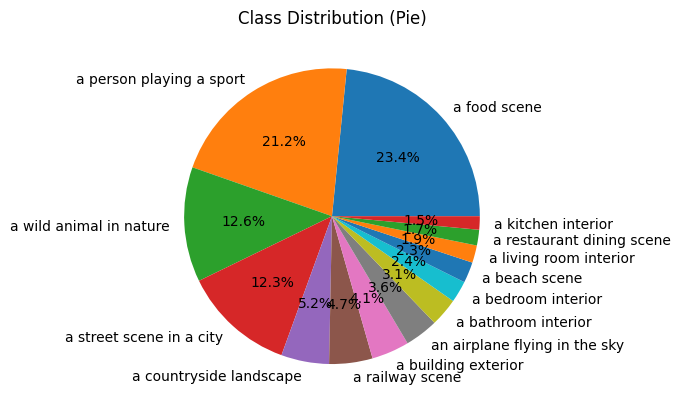

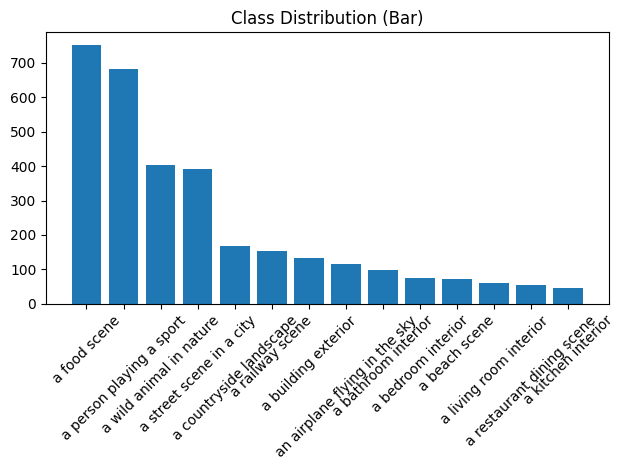

In [ ]:
#analyze_class_distribution(df_clip)

In [21]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

def show_class_images(df, label, image_dir, n=30, cols=5):
    """
    Mostra n immagini di una specifica classe.

    Args:
        df: dataframe con colonne ['image_id', 'labels']
        label: nome della classe
        image_dir: cartella immagini
        n: numero immagini da mostrare
        cols: numero colonne subplot
    """

    subset = df[df["labels"] == label]

    if len(subset) == 0:
        print(f"Nessuna immagine trovata per: {label}")
        return

    n = min(n, len(subset))
    samples = subset.sample(n)

    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3, rows * 3))
    plt.suptitle(label, fontsize=20)

    for i, (_, row) in enumerate(samples.iterrows()):
        plt.subplot(rows, cols, i + 1)

        img_path = os.path.join(image_dir, f"{row['image_id']}.jpg")

        try:
            img = Image.open(img_path).convert("RGB")
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, "ERROR", ha='center', va='center')

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
show_class_images(
    df_clip,
    label="a restaurant dining scene",
    image_dir="../data/images",
    n=30
)

In [23]:
def save_df_csv(df, name):
    df_clean = df[["image_id","objects","labels","obj_list"]]
    df_clean.to_csv(f"../data/{name}.csv", index=False)
    return df_clean

In [24]:
def labeling(df, name):
    df_clip = assign_room_clip(df, "image_id", "../data/images")
    df_clip = save_df_csv(df, f"df_{name}")
    #df_clip_train = pd.read_csv("../data/df_{name}.csv")
    analyze_class_distribution(df)
    
    return df_clip


cuda

📌 Conteggio immagini per classe:

a food scene: 5240
a person playing a sport: 4766
a street scene in a city: 3077
a wild animal in nature: 2849
a countryside landscape: 1120
a railway scene: 1100
a building exterior: 813
an airplane flying in the sky: 696
a bathroom interior: 644
a beach scene: 633
a restaurant dining scene: 419
a bedroom interior: 417
a living room interior: 410
a kitchen interior: 298

Totale immagini: 22482
Numero classi: 14


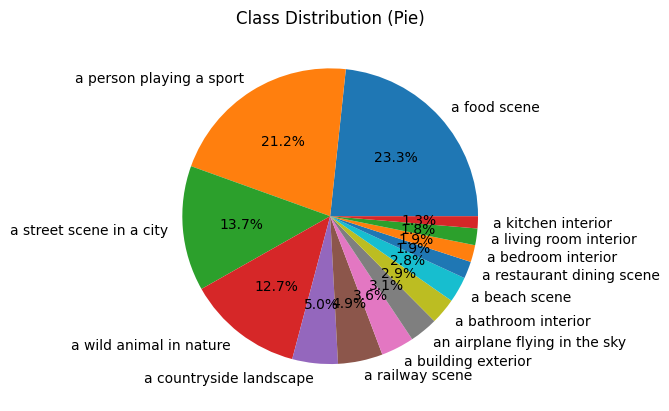

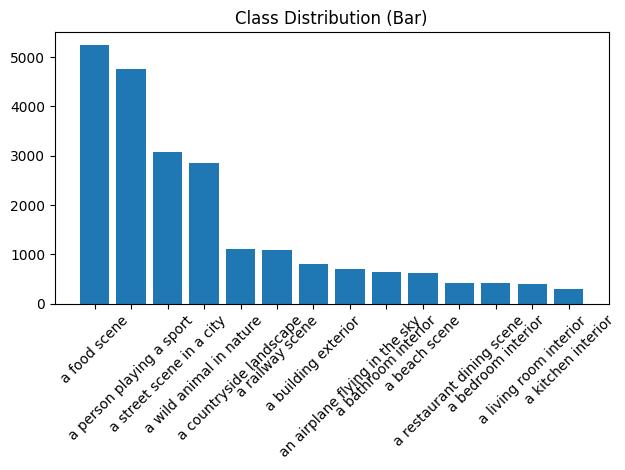

,image_id,objects,labels,obj_list
0,2328363,"{'977890': {'name': 'helmet', 'h': 39, 'relati...",a person playing a sport,"[helmet, shirt, hand, head, pants, belt, field..."
1,2379201,"{'1359959': {'name': 'sky', 'h': 341, 'relatio...",a street scene in a city,"[sky, building, roof, house, road, pole, sign,..."
2,2387152,"{'1278776': {'name': 'woman', 'h': 392, 'relat...",a person playing a sport,"[woman, shoe, ring, head, arm, pole, leg, polo..."
3,2379505,"{'1356974': {'name': 'man', 'h': 333, 'relatio...",a living room interior,"[man, couch, bottle, rug, laptop, shoes, woman..."
4,2407089,"{'323736': {'name': 'boot', 'h': 27, 'relation...",a wild animal in nature,"[boot, people, wheel, coat, bike, woman, shoe,..."
...,...,...,...,...
22477,2397468,"{'1189709': {'name': 'snow', 'h': 272, 'relati...",a person playing a sport,"[snow, pants, coat, hat, sky, sun, mountain, h..."
22478,2360931,"{'3338076': {'name': 'sky', 'h': 227, 'relatio...",a person playing a sport,"[sky, skateboarder, cap, man, tree, cloud, clo..."
22479,498151,"{'4020438': {'name': 'table', 'h': 161, 'relat...",a living room interior,"[table, carpet, door, wall, couches, couch, te..."
22480,500,"{'1635627': {'name': 'cord', 'h': 86, 'relatio...",a food scene,"[cord, outlet, sugar, wall, coffee pot, faucet..."


In [25]:
labeling(df_train_n,"train")

cuda

📌 Conteggio immagini per classe:

a food scene: 751
a person playing a sport: 681
a wild animal in nature: 403
a street scene in a city: 393
a countryside landscape: 168
a railway scene: 152
a building exterior: 132
an airplane flying in the sky: 117
a bathroom interior: 99
a bedroom interior: 76
a beach scene: 73
a living room interior: 61
a restaurant dining scene: 55
a kitchen interior: 47

Totale immagini: 3208
Numero classi: 14


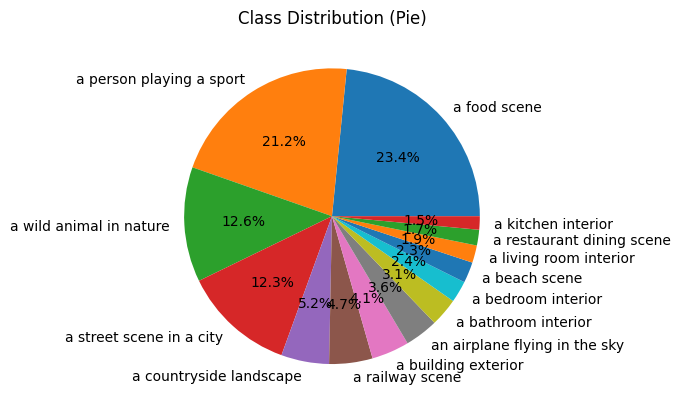

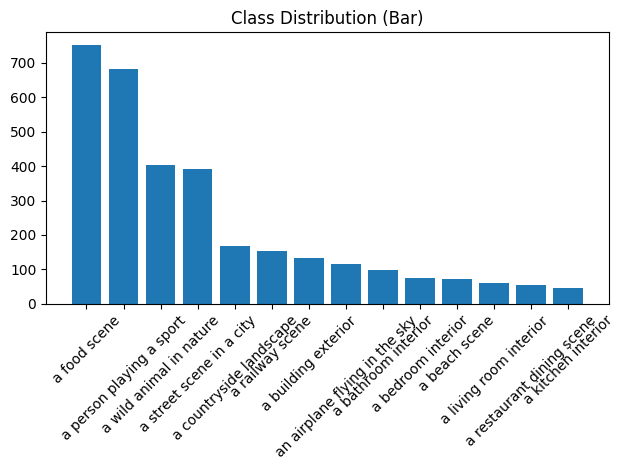

,image_id,objects,labels,obj_list
0,2325919,"{'984369': {'name': 'cabinet', 'h': 96, 'relat...",a kitchen interior,"[cabinet, mirror, refrigerator, stove, microwa..."
1,2384976,"{'1302561': {'name': 'table', 'h': 132, 'relat...",a food scene,"[table, cat, patio, carpet, chair, tail, dog, ..."
2,2327398,"{'3970490': {'name': 'sky', 'h': 114, 'relatio...",a beach scene,"[sky, guy, hand, water, ocean, cloud, beach, s..."
3,2384106,"{'528418': {'name': 'bags', 'h': 70, 'relation...",a wild animal in nature,"[bags, ear, nose, eye, cat, floor, sticker, sh..."
4,2415221,"{'3970837': {'name': 'book', 'h': 103, 'relati...",a food scene,"[book, paw, wall, fur, tail, seat, wallpaper, ..."
...,...,...,...,...
3203,2399231,"{'418119': {'name': 'number', 'h': 17, 'relati...",a railway scene,"[number, sky, clouds, roof, building, train, p..."
3204,2366610,"{'2020239': {'name': 'chopsticks', 'h': 5, 're...",a food scene,"[chopsticks, man, plate, shelf, cheese, glasse..."
3205,2353439,"{'845933': {'name': 'girl', 'h': 102, 'relatio...",a countryside landscape,"[girl, kite, pants, shirt, shoes, undershirt, ..."
3206,2333546,"{'2879990': {'name': 'nose', 'h': 14, 'relatio...",a wild animal in nature,"[nose, zebra, eye, mane, ear, ground, tree]"


In [26]:
labeling(df_val_n,"val")

In [27]:
df_clip_train = pd.read_csv("../data/df_train.csv")
display(df_clip_train.head())
display(df_clip_train.info)

,image_id,objects,labels,obj_list
0,2328363,"{'977890': {'name': 'helmet', 'h': 39, 'relati...",a person playing a sport,"['helmet', 'shirt', 'hand', 'head', 'pants', '..."
1,2379201,"{'1359959': {'name': 'sky', 'h': 341, 'relatio...",a street scene in a city,"['sky', 'building', 'roof', 'house', 'road', '..."
2,2387152,"{'1278776': {'name': 'woman', 'h': 392, 'relat...",a person playing a sport,"['woman', 'shoe', 'ring', 'head', 'arm', 'pole..."
3,2379505,"{'1356974': {'name': 'man', 'h': 333, 'relatio...",a living room interior,"['man', 'couch', 'bottle', 'rug', 'laptop', 's..."
4,2407089,"{'323736': {'name': 'boot', 'h': 27, 'relation...",a wild animal in nature,"['boot', 'people', 'wheel', 'coat', 'bike', 'w..."


<bound method DataFrame.info of        image_id                                            objects  \
0       2328363  {'977890': {'name': 'helmet', 'h': 39, 'relati...   
1       2379201  {'1359959': {'name': 'sky', 'h': 341, 'relatio...   
2       2387152  {'1278776': {'name': 'woman', 'h': 392, 'relat...   
3       2379505  {'1356974': {'name': 'man', 'h': 333, 'relatio...   
4       2407089  {'323736': {'name': 'boot', 'h': 27, 'relation...   
...         ...                                                ...   
22477   2397468  {'1189709': {'name': 'snow', 'h': 272, 'relati...   
22478   2360931  {'3338076': {'name': 'sky', 'h': 227, 'relatio...   
22479    498151  {'4020438': {'name': 'table', 'h': 161, 'relat...   
22480       500  {'1635627': {'name': 'cord', 'h': 86, 'relatio...   
22481   2407660  {'323474': {'name': 'wall', 'h': 311, 'relatio...   

                         labels  \
0      a person playing a sport   
1      a street scene in a city   
2      a person playin

In [28]:
df_clip_val = pd.read_csv("../data/df_val.csv")
display(df_clip_val.head())
display(df_clip_val.info)

,image_id,objects,labels,obj_list
0,2325919,"{'984369': {'name': 'cabinet', 'h': 96, 'relat...",a kitchen interior,"['cabinet', 'mirror', 'refrigerator', 'stove',..."
1,2384976,"{'1302561': {'name': 'table', 'h': 132, 'relat...",a food scene,"['table', 'cat', 'patio', 'carpet', 'chair', '..."
2,2327398,"{'3970490': {'name': 'sky', 'h': 114, 'relatio...",a beach scene,"['sky', 'guy', 'hand', 'water', 'ocean', 'clou..."
3,2384106,"{'528418': {'name': 'bags', 'h': 70, 'relation...",a wild animal in nature,"['bags', 'ear', 'nose', 'eye', 'cat', 'floor',..."
4,2415221,"{'3970837': {'name': 'book', 'h': 103, 'relati...",a food scene,"['book', 'paw', 'wall', 'fur', 'tail', 'seat',..."


<bound method DataFrame.info of       image_id                                            objects  \
0      2325919  {'984369': {'name': 'cabinet', 'h': 96, 'relat...   
1      2384976  {'1302561': {'name': 'table', 'h': 132, 'relat...   
2      2327398  {'3970490': {'name': 'sky', 'h': 114, 'relatio...   
3      2384106  {'528418': {'name': 'bags', 'h': 70, 'relation...   
4      2415221  {'3970837': {'name': 'book', 'h': 103, 'relati...   
...        ...                                                ...   
3203   2399231  {'418119': {'name': 'number', 'h': 17, 'relati...   
3204   2366610  {'2020239': {'name': 'chopsticks', 'h': 5, 're...   
3205   2353439  {'845933': {'name': 'girl', 'h': 102, 'relatio...   
3206   2333546  {'2879990': {'name': 'nose', 'h': 14, 'relatio...   
3207   2360109  {'1755926': {'name': 'man', 'h': 173, 'relatio...   

                        labels  \
0           a kitchen interior   
1                 a food scene   
2                a beach scene   
3  

Il dataset risulta estremamente sbilanciato con le classi attuali -> cronologia etichette

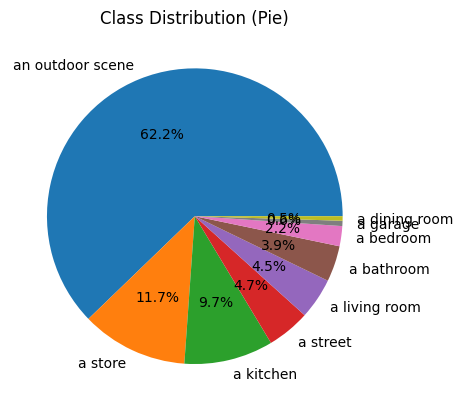
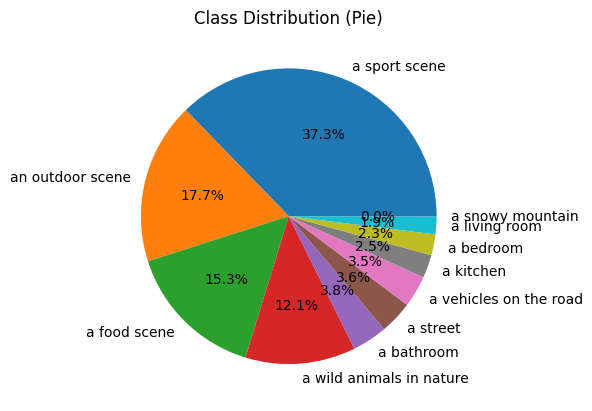
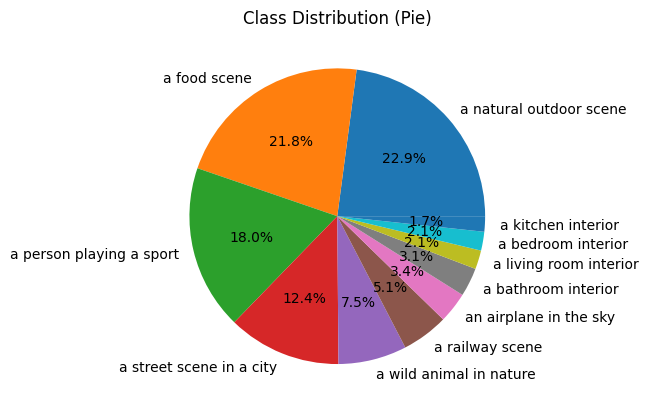
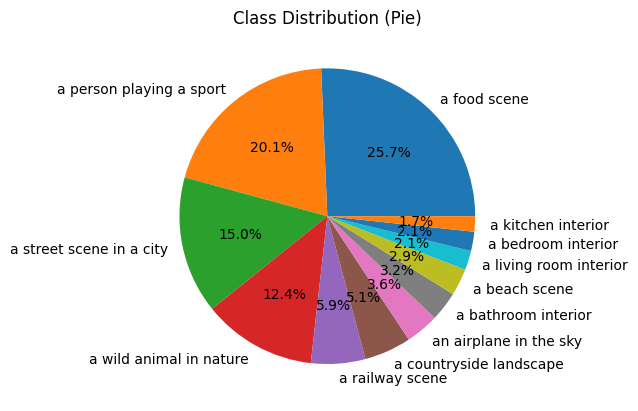
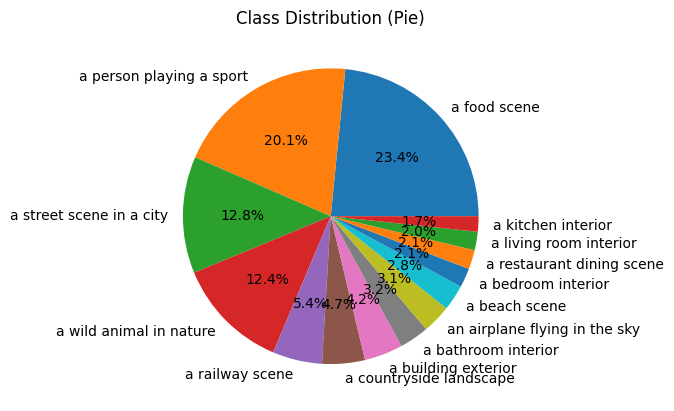